# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">The Severity Prediction of the Binary and Multi-Class Cardiovascular Disease: A Machine Learning-Based Fusion Approach </p>


***This is third Code for binary class fusion model-3 (ADA+DT) using weighted score fusion***

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.tree import DecisionTreeClassifier 
from matplotlib import pyplot as plt
from sklearn import tree
import numpy
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import sklearn.metrics as metrics
from sklearn.ensemble import AdaBoostClassifier

In [2]:
data = pd.read_csv('binary classification.csv')
data.head(10)

,age,chest pain,restBP,cholesterol,max HR,exerc ind ang,ST by exercise,slope,major vessels colored,thal,gender,fasting blood sugar,rest ECG,target
0,63,3,145,233,150,0,2.3,0,0,0,1,1,1,0
1,67,0,160,286,108,1,1.5,1,3,1,1,0,1,1
2,67,0,120,229,129,1,2.6,1,2,2,1,0,1,1
3,37,2,130,250,187,0,3.5,0,0,1,1,0,2,0
4,41,1,130,204,172,0,1.4,2,0,1,0,0,1,0
5,56,1,120,236,178,0,0.8,2,0,1,1,0,2,0
6,62,0,140,268,160,0,3.6,0,2,1,0,0,1,1
7,57,0,120,354,163,1,0.6,2,0,1,0,0,2,0
8,63,0,130,254,147,0,1.4,1,1,2,1,0,1,1
9,53,0,140,203,155,1,3.1,0,0,2,1,1,1,1


In [3]:
x = data.iloc[:,0:13].values
y = data.iloc[:,13].values

In [4]:
#for 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

#for 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)

#StandardScaler for normalization for some algortihms
sc = StandardScaler()

#min-max scaler for normalization for some algortihms
scaler = MinMaxScaler(feature_range=(0,1))

"""Information based algorithms (Decision Trees, Random Forests) and probability based algorithms (Naive Bayes, Bayesian Networks) don't require normalization either."""

#code for decision tree

model1 = tree.DecisionTreeClassifier(criterion= 'gini',
                                                 max_depth= 8,
                                                 max_features= 8,
                                                 min_samples_leaf=7,
                                                 splitter= 'random')

In [5]:
# No normalization

X_train_dt=X_train
X_test_dt=X_test

model1.fit(X_train_dt,y_train)
rounded_predictions1 = model1.predict(X_test_dt)
predictions1 =model1.predict_proba(X_test_dt)
y_pred1 = rounded_predictions1


In [12]:
import sklearn.metrics as metrics
scores1=metrics.accuracy_score(y_test,y_pred1)
print("Accuracy of DT = ",scores1)  

print(metrics.confusion_matrix(y_test,y_pred1))
print(metrics.classification_report(y_test,y_pred1))

fpr1, tpr1, threshold = metrics.roc_curve(y_pred1,y_test)
roc_auc1 = metrics.auc(fpr1, tpr1)
print("roc_auc_DT",roc_auc1)

Accuracy of DT =  0.8021978021978022
[[42  6]
 [12 31]]
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        48
           1       0.84      0.72      0.78        43

    accuracy                           0.80        91
   macro avg       0.81      0.80      0.80        91
weighted avg       0.81      0.80      0.80        91

roc_auc_DT 0.8078078078078078


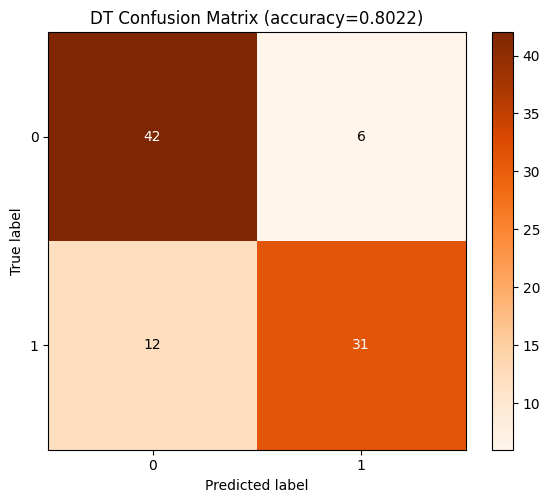

In [14]:
# Confusion matrix heatmap for the trained Decision Tree (DT)
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix between true labels and DT predictions (y_pred1)
cm_dt = confusion_matrix(y_test, y_pred1)
acc_dt = accuracy_score(y_test, y_pred1)
labels = np.unique(np.concatenate((y_test, y_pred1)))

# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_dt, interpolation='nearest', cmap=plt.cm.Oranges)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'DT Confusion Matrix (accuracy={acc_dt:.4f})')
thresh = cm_dt.max() / 2.0
for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        ax.text(j, i, format(cm_dt[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_dt[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()


roc_auc_DT 0.8607073643410853


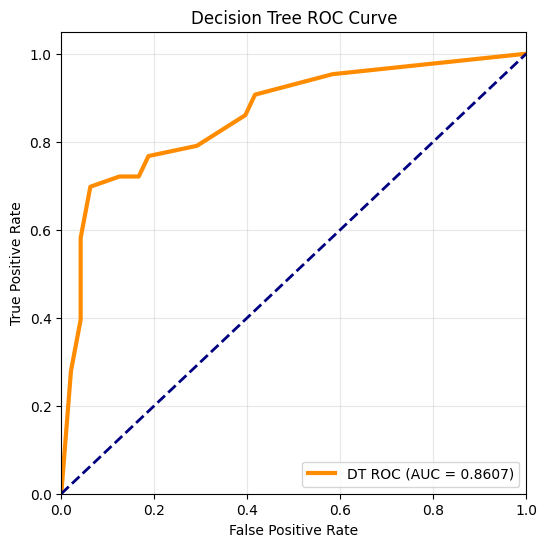

In [16]:
# ROC-AUC curve for the trained Decision Tree (DT)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Use predicted probabilities for the positive class if available
try:
    y_score_dt = predictions1[:, 1]  # probability of positive class
except Exception:
    # Fallback to predicted labels if probabilities are not available
    y_score_dt = y_pred1

# Compute ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
print("roc_auc_DT", roc_auc_dt)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=3, label=f'DT ROC (AUC = {roc_auc_dt:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [7]:
# code for adaboost

model2 = AdaBoostClassifier(n_estimators=200,
                         learning_rate=.01)



X_train_dt = X_train[:,0:13]
X_test_dt = X_test[:,0:13]

model2.fit(X_train_dt,y_train)
           
rounded_predictions2 = model2.predict(X_test_dt)
predictions2 =model2.predict_proba(X_test_dt)
y_pred2 = rounded_predictions2


model2.fit(X_train_dt,y_train)
           
rounded_predictions2 = model2.predict(X_test_dt)
predictions2 =model2.predict_proba(X_test_dt)
y_pred2 = rounded_predictions2

In [17]:
import sklearn.metrics as metrics
scores2=metrics.accuracy_score(y_test,y_pred2)
print("Accuracy of ADA = ",scores2)  

print(metrics.confusion_matrix(y_test,y_pred2))
print(metrics.classification_report(y_test,y_pred2))

fpr2, tpr2, threshold = metrics.roc_curve(y_pred2,y_test)
roc_auc2 = metrics.auc(fpr2, tpr2)
print("roc_auc_ADA",roc_auc2)

Accuracy of ADA =  0.8461538461538461
[[43  5]
 [ 9 34]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        48
           1       0.87      0.79      0.83        43

    accuracy                           0.85        91
   macro avg       0.85      0.84      0.84        91
weighted avg       0.85      0.85      0.85        91

roc_auc_ADA 0.8493589743589743


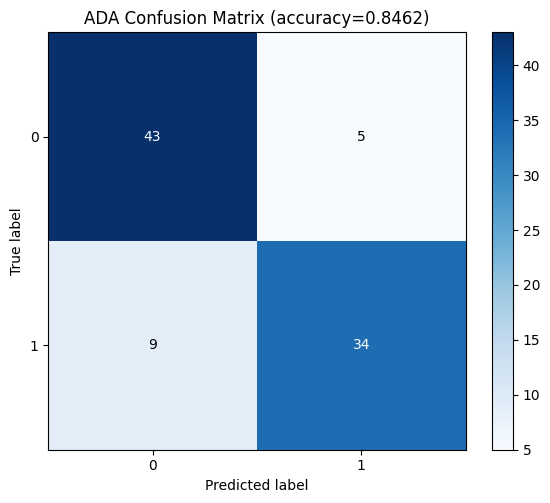

In [20]:
# Confusion matrix heatmap for the trained AdaBoost (ADA) model
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix between true labels and ADA predictions (y_pred2)
cm_ada = confusion_matrix(y_test, y_pred2)
acc_ada = accuracy_score(y_test, y_pred2)
labels = np.unique(np.concatenate((y_test, y_pred2)))

# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_ada, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'ADA Confusion Matrix (accuracy={acc_ada:.4f})')
thresh = cm_ada.max() / 2.0
for i in range(cm_ada.shape[0]):
    for j in range(cm_ada.shape[1]):
        ax.text(j, i, format(cm_ada[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_ada[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()


roc_auc_ADA 0.9125484496124031


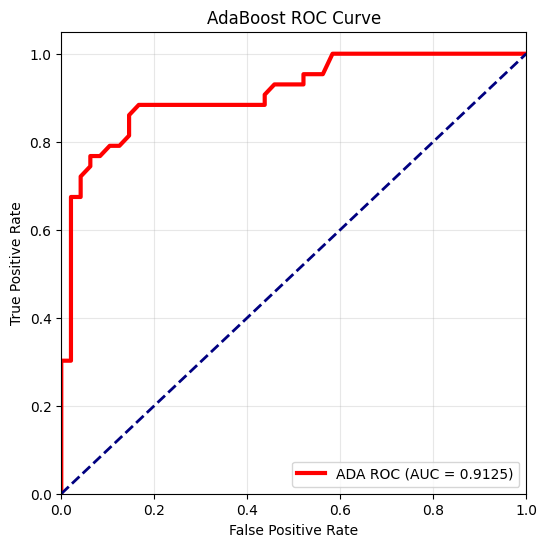

In [21]:
# ROC-AUC curve for the trained AdaBoost (ADA) model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Use predicted probabilities for the positive class if available
try:
    y_score_ada = predictions2[:, 1]  # probability of positive class
except Exception:
    # Fallback to predicted labels if probabilities are not available
    y_score_ada = y_pred2

# Compute ROC curve and AUC for AdaBoost
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_score_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)
print("roc_auc_ADA", roc_auc_ada)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_ada, tpr_ada, color='red', lw=3, label=f'ADA ROC (AUC = {roc_auc_ada:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [9]:
#weighted fusion
#same procedure for every model(1,2 and 3). for every model we need to take the prediction 
# values and then the values will be merged according to the procedure given in below.

#selecting the best value for p and q(p & q represents the weights w1 & w2)

p=1
#q=1-p
for i in range (19):
    p=p-.05
    q=1-p

  
    mixed=predictions1[:,1]*p+predictions2[:,1]*q
    rounded_mixed=mixed
    for i in range(len(y_test)):
        if mixed[i]>.5:
            rounded_mixed[i]=1
        else:
             rounded_mixed[i]=0

    score=metrics.accuracy_score(rounded_mixed,y_test)
    print("  mixed  p  q","%.4f" %score, "%.2f" %p,"%.2f" %q)

  mixed  p  q 0.8022 0.95 0.05
  mixed  p  q 0.8022 0.90 0.10
  mixed  p  q 0.8022 0.85 0.15
  mixed  p  q 0.8132 0.80 0.20
  mixed  p  q 0.8242 0.75 0.25
  mixed  p  q 0.8352 0.70 0.30
  mixed  p  q 0.8571 0.65 0.35
  mixed  p  q 0.8571 0.60 0.40
  mixed  p  q 0.8571 0.55 0.45
  mixed  p  q 0.8681 0.50 0.50
  mixed  p  q 0.8681 0.45 0.55
  mixed  p  q 0.8901 0.40 0.60
  mixed  p  q 0.9121 0.35 0.65
  mixed  p  q 0.9121 0.30 0.70
  mixed  p  q 0.8791 0.25 0.75
  mixed  p  q 0.8791 0.20 0.80
  mixed  p  q 0.8791 0.15 0.85
  mixed  p  q 0.8681 0.10 0.90
  mixed  p  q 0.8462 0.05 0.95


In [22]:
#after selecting the value of p and q which gives the highest accuracy. This value differs for different algorithms.
p=.05
q=1-p

mixed=predictions1[:,1]*p+predictions2[:,1]*q
rounded_mixed=mixed
for i in range(len(y_test)):
    if mixed[i]>=.5:
        rounded_mixed[i]=1
    else:
         rounded_mixed[i]=0
            
score=metrics.accuracy_score(rounded_mixed,y_test)
print("Ensembled accuracy(DT+ADA)= ",score)

print(metrics.confusion_matrix(y_test,rounded_mixed))
print(metrics.classification_report(y_test,rounded_mixed))

fpr, tpr, threshold = metrics.roc_curve(rounded_mixed,y_test)
roc_auc = metrics.auc(fpr, tpr)
print("roc_auc_tot",roc_auc)

Ensembled accuracy(DT+ADA)=  0.8461538461538461
[[43  5]
 [ 9 34]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        48
           1       0.87      0.79      0.83        43

    accuracy                           0.85        91
   macro avg       0.85      0.84      0.84        91
weighted avg       0.85      0.85      0.85        91

roc_auc_tot 0.8493589743589743


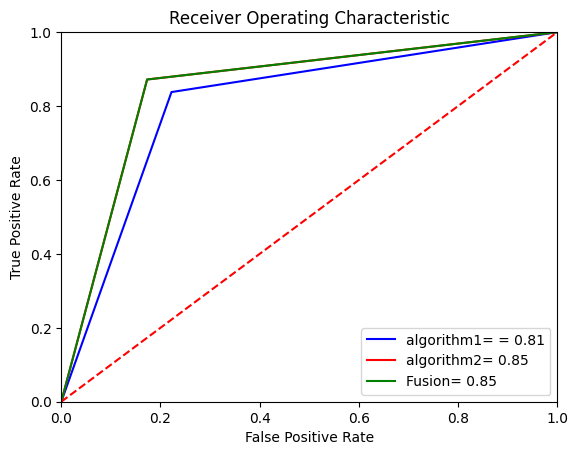

In [23]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr1, tpr1, 'b', label = 'algorithm1= = %0.2f' % roc_auc1)
plt.plot(fpr2, tpr2, 'r', label = 'algorithm2= %0.2f' % roc_auc2)
plt.plot(fpr, tpr, 'g', label = 'Fusion= %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [ ]:
# Confusion matrix heatmap for the ensembled model (DT + ADA)
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# rounded_mixed holds the ensembled binary predictions; y_test are true labels
cm_ens = confusion_matrix(y_test, rounded_mixed)
acc_ens = accuracy_score(y_test, rounded_mixed)
labels = np.unique(np.concatenate((y_test, rounded_mixed)))

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm_ens, interpolation='nearest', cmap=plt.cm.Purples)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'Ensemble (DT+ADA) Confusion Matrix (accuracy={acc_ens:.4f})')
thresh = cm_ens.max() / 2.0
for i in range(cm_ens.shape[0]):
    for j in range(cm_ens.shape[1]):
        ax.text(j, i, format(cm_ens[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_ens[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()


In [ ]:
# ROC-AUC curve for the ensembled model (DT + ADA)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Use the continuous mixed scores (before rounding) if available; else fall back to rounded_mixed
try:
    # 'mixed' was computed earlier as weighted probabilities: use it if present
    y_score_ens = mixed
except NameError:
    # Fallback to rounded predictions (will give a step-like ROC)
    y_score_ens = rounded_mixed

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_score_ens)
roc_auc_ens = auc(fpr_ens, tpr_ens)
print("roc_auc_Ensemble(DT+ADA)", roc_auc_ens)

plt.figure(figsize=(6,6))
plt.plot(fpr_ens, tpr_ens, color='green', lw=3, label=f'Ensemble ROC (AUC = {roc_auc_ens:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble (DT+ADA) ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
